In [ ]:
!pip install earthaccess
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.5/70.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.0/201.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 5.2 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.0.0
    Uninstalling wrapt-2.0.0:
      Successfully uninstalled wrapt-2.0.0
  Attempting uninstall: tenacity
    Found existing installation: tenacity 8.5.0
    Uninstalling tenacity-8.5.0:
      Successfully uninstalled tenacity-8.5.0
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Conv2D, ConvLSTM2D,
                                      Reshape, Input, TimeDistributed)
from tensorflow.keras.optimizers import Adam
import xarray as xr
import earthaccess
import warnings
warnings.filterwarnings('ignore')

print("Initializing Earth Access authentication...")
try:
    auth = earthaccess.login()
    print("✓ Earth Access authenticated!")
except Exception as e:
    print(f"⚠ Earth Access login warning: {e}")
    print("Proceeding with synthetic data generation...")

Initializing Earth Access authentication...
Enter your Earthdata Login username: poorani_11
Enter your Earthdata password: ··········
✓ Earth Access authenticated!


In [ ]:
def create_synthetic_sst_data(time_steps=365*5, height=64, width=64):
    """Create realistic synthetic SST data for Indian and Pacific Ocean"""
    print(f"Creating synthetic SST data...")
    print(f"  Time steps: {time_steps}, Height: {height}, Width: {width}")

    # Indian Ocean region (40°E-120°E, 30°S-30°N)
    indian_data = np.zeros((time_steps, height, width))
    for t in range(time_steps):
        base = 25 + 5 * np.sin(2 * np.pi * t / 365)
        spatial_pattern = np.random.normal(0, 0.5, (height, width))
        x, y = np.meshgrid(np.linspace(0, 1, width), np.linspace(0, 1, height))
        trend = 3 * (0.5 - x) + 2 * (y - 0.5)
        indian_data[t] = base + spatial_pattern + trend

    # Pacific Ocean region (110°E-180°, 30°S-30°N)
    pacific_data = np.zeros((time_steps, height, width))
    for t in range(time_steps):
        base = 24 + 6 * np.sin(2 * np.pi * t / 365)
        spatial_pattern = np.random.normal(0, 0.5, (height, width))
        x, y = np.meshgrid(np.linspace(0, 1, width), np.linspace(0, 1, height))
        trend = 2 * (0.3 - x) + 3 * (0.5 - np.abs(y - 0.5))
        pacific_data[t] = base + spatial_pattern + trend

    print(f"✓ Indian Ocean data shape: {indian_data.shape}")
    print(f"✓ Pacific Ocean data shape: {pacific_data.shape}")
    return indian_data, pacific_data

# Run this cell
indian_data, pacific_data = create_synthetic_sst_data(time_steps=365*5, height=64, width=64)


Creating synthetic SST data...
  Time steps: 1825, Height: 64, Width: 64
✓ Indian Ocean data shape: (1825, 64, 64)
✓ Pacific Ocean data shape: (1825, 64, 64)


In [ ]:
def preprocess_data(data, train_ratio=0.8, lookback=10):
    """Normalize and create sequences"""
    print(f"Preprocessing data with lookback={lookback}...")

    T, H, W = data.shape
    scaler = MinMaxScaler()

    # Flatten and scale
    data_flat = data.reshape(-1, 1)
    data_scaled = scaler.fit_transform(data_flat).reshape(T, H, W)

    # Create sequences
    X, y = [], []
    for i in range(len(data_scaled) - lookback):
        X.append(data_scaled[i:i+lookback])
        y.append(data_scaled[i+lookback:i+lookback+1])

    X, y = np.array(X), np.array(y)

    # Add channel dimension
    X = np.expand_dims(X, axis=-1)
    y = np.squeeze(y, axis=1)

    # Train-test split
    split_idx = int(len(X) * train_ratio)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    print(f"  X_train shape: {X_train.shape}")
    print(f"  y_train shape: {y_train.shape}")
    print(f"  X_test shape: {X_test.shape}")
    print(f"  y_test shape: {y_test.shape}")

    return X_train, y_train, X_test, y_test, scaler

# Preprocess Indian Ocean
print("\n" + "="*60)
print("PREPROCESSING: INDIAN OCEAN")
print("="*60)
X_train_i, y_train_i, X_test_i, y_test_i, scaler_i = preprocess_data(
    indian_data, lookback=10
)




PREPROCESSING: INDIAN OCEAN
Preprocessing data with lookback=10...
  X_train shape: (1452, 10, 64, 64, 1)
  y_train shape: (1452, 64, 64)
  X_test shape: (363, 10, 64, 64, 1)
  y_test shape: (363, 64, 64)


In [ ]:
print("\n" + "="*60)
print("PREPROCESSING: PACIFIC OCEAN")
print("="*60)
X_train_p, y_train_p, X_test_p, y_test_p, scaler_p = preprocess_data(
    pacific_data, lookback=10
)


PREPROCESSING: PACIFIC OCEAN
Preprocessing data with lookback=10...
  X_train shape: (1452, 10, 64, 64, 1)
  y_train shape: (1452, 64, 64)
  X_test shape: (363, 10, 64, 64, 1)
  y_test shape: (363, 64, 64)


In [ ]:
def build_convlstm_model(input_shape):
    """ConvLSTM model for spatio-temporal forecasting"""
    print("Building ConvLSTM model...")

    model = Sequential([
        ConvLSTM2D(filters=32, kernel_size=(3, 3), input_shape=input_shape,
                   activation='relu', padding='same', return_sequences=True),
        ConvLSTM2D(filters=64, kernel_size=(3, 3), activation='relu',
                   padding='same', return_sequences=True),
        ConvLSTM2D(filters=32, kernel_size=(3, 3), activation='relu',
                   padding='same', return_sequences=False),
        Conv2D(filters=1, kernel_size=(3, 3), activation='sigmoid', padding='same')
    ])

    model.summary()
    return model

print("\n" + "="*60)
print("MODEL ARCHITECTURE: ConvLSTM")
print("="*60)
input_shape = (10, 64, 64, 1)
convlstm_model = build_convlstm_model(input_shape)



MODEL ARCHITECTURE: ConvLSTM
Building ConvLSTM model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 10, 64, 64, 32) │        38,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 10, 64, 64, 64) │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)      │ (None, 64, 64, 32)     │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 370,593 (1.41 MB)

 Trainable params: 370,593 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_cnn_lstm_model(input_shape):
    """CNN-LSTM model for spatio-temporal forecasting"""
    print("Building CNN-LSTM model...")

    inputs = Input(shape=input_shape)

    x = TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same'))(inputs)
    x = TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same'))(x)
    x = TimeDistributed(Reshape((-1,)))(x)

    x = LSTM(128, activation='relu', return_sequences=True)(x)
    x = LSTM(64, activation='relu', return_sequences=False)(x)

    x = Dense(input_shape[1] * input_shape[2] * 32)(x)
    x = Reshape((input_shape[1], input_shape[2], 32))(x)

    outputs = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    model = Model(inputs, outputs)
    model.summary()
    return model

print("\n" + "="*60)
print("MODEL ARCHITECTURE: CNN-LSTM")
print("="*60)
cnnlstm_model = build_cnn_lstm_model(input_shape)



MODEL ARCHITECTURE: CNN-LSTM
Building CNN-LSTM model...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10, 64, 64, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 64, 64, 32) │           320 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 64, 64, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 262144)     │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 128)        │   134,283,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 131072)         │     8,519,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,871,969 (545.01 MB)

 Trainable params: 142,871,969 (545.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def train_model(model, X_train, y_train, X_test, y_test, model_name, epochs=20, batch_size=16):
    """Train the model"""
    print(f"\nTraining {model_name}...")

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    return model, history

print("\n" + "="*60)
print("TRAINING: ConvLSTM - Indian Ocean")
print("="*60)
convlstm_i = build_convlstm_model(input_shape)
convlstm_i, hist_convlstm_i = train_model(
    convlstm_i, X_train_i, y_train_i, X_test_i, y_test_i,
    "ConvLSTM-Indian", epochs=20, batch_size=16
)


TRAINING: ConvLSTM - Indian Ocean
Building ConvLSTM model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d_3 (ConvLSTM2D)      │ (None, 10, 64, 64, 32) │        38,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_4 (ConvLSTM2D)      │ (None, 10, 64, 64, 64) │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_5 (ConvLSTM2D)      │ (None, 64, 64, 32)     │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 370,593 (1.41 MB)

 Trainable params: 370,593 (1.41 MB)

 Non-trainable params: 0 (0.00 B)


Training ConvLSTM-Indian...
Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 71s 600ms/step - loss: 0.0238 - mae: 0.1189 - val_loss: 0.0019 - val_mae: 0.0348
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 48s 528ms/step - loss: 0.0021 - mae: 0.0363 - val_loss: 0.0014 - val_mae: 0.0304
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 47s 518ms/step - loss: 0.0015 - mae: 0.0307 - val_loss: 0.0014 - val_mae: 0.0297
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 47s 522ms/step - loss: 0.0014 - mae: 0.0306 - val_loss: 0.0013 - val_mae: 0.0290
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 47s 520ms/step - loss: 0.0014 - mae: 0.0300 - val_loss: 0.0014 - val_mae: 0.0296
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 82s 522ms/step - loss: 0.0014 - mae: 0.0305 - val_loss: 0.0012 - val_mae: 0.0282
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 81s 514ms/step - loss: 0.0013 - mae: 0.0285 - val_loss: 0.0012 - val_mae: 0.0279
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 47s 518ms/step - loss: 0.0013 - mae: 0.0286 - val_loss: 0.0011 - val_mae: 0.0261
Epoch 9/20
91/91 ━━

In [ ]:
print("\n" + "="*60)
print("TRAINING: CNN-LSTM - Indian Ocean")
print("="*60)
cnnlstm_i = build_cnn_lstm_model(input_shape)
cnnlstm_i, hist_cnnlstm_i = train_model(
    cnnlstm_i, X_train_i, y_train_i, X_test_i, y_test_i,
    "CNN-LSTM-Indian", epochs=20, batch_size=16
)


TRAINING: CNN-LSTM - Indian Ocean
Building CNN-LSTM model...


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 10, 64, 64, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 64, 64, 32) │           320 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 10, 64, 64, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 10, 262144)     │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 128)        │   134,283,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 131072)         │     8,519,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,871,969 (545.01 MB)

 Trainable params: 142,871,969 (545.01 MB)

 Non-trainable params: 0 (0.00 B)


Training CNN-LSTM-Indian...
Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 50s 435ms/step - loss: 0.0398 - mae: 0.1462 - val_loss: 0.0012 - val_mae: 0.0277
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 30s 335ms/step - loss: 0.0015 - mae: 0.0311 - val_loss: 0.0015 - val_mae: 0.0308
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 41s 335ms/step - loss: 0.0010 - mae: 0.0253 - val_loss: 9.0538e-04 - val_mae: 0.0240
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 30s 334ms/step - loss: 8.8831e-04 - mae: 0.0238 - val_loss: 8.7527e-04 - val_mae: 0.0236
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 30s 334ms/step - loss: 8.5872e-04 - mae: 0.0234 - val_loss: 0.0010 - val_mae: 0.0253
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 30s 334ms/step - loss: 8.6116e-04 - mae: 0.0234 - val_loss: 8.1316e-04 - val_mae: 0.0228
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 30s 335ms/step - loss: 8.4698e-04 - mae: 0.0232 - val_loss: 8.5974e-04 - val_mae: 0.0234
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 30s 334ms/step - loss: 0.0011 - mae: 0.0258 - val_loss: 8.5088e-04 -

In [ ]:
print("\n" + "="*60)
print("TRAINING: ConvLSTM - Pacific Ocean")
print("="*60)
convlstm_p = build_convlstm_model(input_shape)
convlstm_p, hist_convlstm_p = train_model(
    convlstm_p, X_train_p, y_train_p, X_test_p, y_test_p,
    "ConvLSTM-Pacific", epochs=20, batch_size=16
)


TRAINING: ConvLSTM - Pacific Ocean
Building ConvLSTM model...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d_6 (ConvLSTM2D)      │ (None, 10, 64, 64, 32) │        38,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_7 (ConvLSTM2D)      │ (None, 10, 64, 64, 64) │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_8 (ConvLSTM2D)      │ (None, 64, 64, 32)     │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 370,593 (1.41 MB)

 Trainable params: 370,593 (1.41 MB)

 Non-trainable params: 0 (0.00 B)


Training ConvLSTM-Pacific...
Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 63s 595ms/step - loss: 0.0261 - mae: 0.1257 - val_loss: 0.0020 - val_mae: 0.0358
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 71s 524ms/step - loss: 0.0020 - mae: 0.0353 - val_loss: 0.0015 - val_mae: 0.0318
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 47s 519ms/step - loss: 0.0016 - mae: 0.0329 - val_loss: 0.0015 - val_mae: 0.0318
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 47s 521ms/step - loss: 0.0017 - mae: 0.0332 - val_loss: 0.0026 - val_mae: 0.0425
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 47s 520ms/step - loss: 0.0017 - mae: 0.0332 - val_loss: 0.0024 - val_mae: 0.0400
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 47s 521ms/step - loss: 0.0018 - mae: 0.0341 - val_loss: 0.0019 - val_mae: 0.0342
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 47s 519ms/step - loss: 0.0024 - mae: 0.0394 - val_loss: 0.0013 - val_mae: 0.0297
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 47s 519ms/step - loss: 0.0013 - mae: 0.0293 - val_loss: 0.0013 - val_mae: 0.0284
Epoch 9/20
91/91 ━

In [ ]:
print("\n" + "="*60)
print("TRAINING: CNN-LSTM - Pacific Ocean")
print("="*60)
cnnlstm_p = build_cnn_lstm_model(input_shape)
cnnlstm_p, hist_cnnlstm_p = train_model(
    cnnlstm_p, X_train_p, y_train_p, X_test_p, y_test_p,
    "CNN-LSTM-Pacific", epochs=20, batch_size=16
)


TRAINING: CNN-LSTM - Pacific Ocean
Building CNN-LSTM model...


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 10, 64, 64, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 10, 64, 64, 32) │           320 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 10, 64, 64, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 10, 262144)     │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 10, 128)        │   134,283,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 131072)         │     8,519,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,871,969 (545.01 MB)

 Trainable params: 142,871,969 (545.01 MB)

 Non-trainable params: 0 (0.00 B)


Training CNN-LSTM-Pacific...
Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 46s 410ms/step - loss: 0.0321 - mae: 0.1338 - val_loss: 0.0016 - val_mae: 0.0318
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 30s 335ms/step - loss: 0.0010 - mae: 0.0250 - val_loss: 8.2740e-04 - val_mae: 0.0229
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 30s 334ms/step - loss: 0.0012 - mae: 0.0273 - val_loss: 8.0784e-04 - val_mae: 0.0227
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 30s 334ms/step - loss: 8.8609e-04 - mae: 0.0237 - val_loss: 0.0015 - val_mae: 0.0307
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 30s 334ms/step - loss: 9.2919e-04 - mae: 0.0243 - val_loss: 7.3600e-04 - val_mae: 0.0216
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 30s 334ms/step - loss: 7.5180e-04 - mae: 0.0219 - val_loss: 7.4889e-04 - val_mae: 0.0218
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 30s 334ms/step - loss: 0.0012 - mae: 0.0267 - val_loss: 8.5645e-04 - val_mae: 0.0234
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 30s 334ms/step - loss: 8.9354e-04 - mae: 0.0238 - val_loss: 8.5390e

In [ ]:
def evaluate_model(model, X_test, y_test, scaler, model_name):
    """Evaluate model and compute metrics"""
    print(f"\nEvaluating {model_name}...")

    y_pred = model.predict(X_test)

    # Flatten for metric calculation
    y_test_flat = y_test.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)

    # Remove NaN and Inf values
    mask = np.isfinite(y_test_flat) & np.isfinite(y_pred_flat)
    y_test_flat = y_test_flat[mask]
    y_pred_flat = y_pred_flat[mask]

    # Compute metrics
    rmse = np.sqrt(mean_squared_error(y_test_flat, y_pred_flat))
    mae = mean_absolute_error(y_test_flat, y_pred_flat)

    # Accuracy (as correlation)
    if len(y_test_flat) > 1:
        try:
            accuracy = np.corrcoef(y_test_flat, y_pred_flat)[0, 1]
        except:
            accuracy = 0.0
    else:
        accuracy = 0.0

    # Threshold-based accuracy
    threshold = np.std(y_test_flat) / 2
    acc = np.mean(np.abs(y_test_flat - y_pred_flat) < threshold)

    metrics = {
        'RMSE': rmse,
        'MAE': mae,
        'Accuracy': accuracy,
        'Acc': acc
    }

    print(f"\n{model_name} Performance Metrics:")
    print(f"  RMSE:     {rmse:.4f}")
    print(f"  MAE:      {mae:.4f}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Acc:      {acc:.4f}")

    return y_pred, metrics

# Evaluate Indian Ocean models
print("\n" + "="*60)
print("EVALUATION: INDIAN OCEAN MODELS")
print("="*60)
y_pred_convlstm_i, metrics_convlstm_i = evaluate_model(
    convlstm_i, X_test_i, y_test_i, scaler_i, "ConvLSTM-Indian"
)
y_pred_cnnlstm_i, metrics_cnnlstm_i = evaluate_model(
    cnnlstm_i, X_test_i, y_test_i, scaler_i, "CNN-LSTM-Indian"
)


EVALUATION: INDIAN OCEAN MODELS

Evaluating ConvLSTM-Indian...
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 346ms/step

ConvLSTM-Indian Performance Metrics:
  RMSE:     0.0281
  MAE:      0.0224
  Accuracy: 0.9908
  Acc:      0.9998

Evaluating CNN-LSTM-Indian...
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step

CNN-LSTM-Indian Performance Metrics:
  RMSE:     0.0281
  MAE:      0.0224
  Accuracy: 0.9907
  Acc:      0.9998


In [ ]:
print("\n" + "="*60)
print("EVALUATION: PACIFIC OCEAN MODELS")
print("="*60)
y_pred_convlstm_p, metrics_convlstm_p = evaluate_model(
    convlstm_p, X_test_p, y_test_p, scaler_p, "ConvLSTM-Pacific"
)
y_pred_cnnlstm_p, metrics_cnnlstm_p = evaluate_model(
    cnnlstm_p, X_test_p, y_test_p, scaler_p, "CNN-LSTM-Pacific"
)


EVALUATION: PACIFIC OCEAN MODELS

Evaluating ConvLSTM-Pacific...
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 347ms/step

ConvLSTM-Pacific Performance Metrics:
  RMSE:     0.0273
  MAE:      0.0218
  Accuracy: 0.9932
  Acc:      1.0000

Evaluating CNN-LSTM-Pacific...
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step

CNN-LSTM-Pacific Performance Metrics:
  RMSE:     0.0275
  MAE:      0.0220
  Accuracy: 0.9931
  Acc:      1.0000


In [ ]:
print("\n" + "="*60)
print("METRICS SUMMARY - ALL MODELS")
print("="*60)

metrics_df = pd.DataFrame({
    'ConvLSTM-Indian': metrics_convlstm_i,
    'CNN-LSTM-Indian': metrics_cnnlstm_i,
    'ConvLSTM-Pacific': metrics_convlstm_p,
    'CNN-LSTM-Pacific': metrics_cnnlstm_p
})

print(metrics_df.round(4).to_string())


METRICS SUMMARY - ALL MODELS
          ConvLSTM-Indian  CNN-LSTM-Indian  ConvLSTM-Pacific  CNN-LSTM-Pacific
RMSE               0.0281           0.0281            0.0273            0.0275
MAE                0.0224           0.0224            0.0218            0.0220
Accuracy           0.9908           0.9907            0.9932            0.9931
Acc                0.9998           0.9998            1.0000            1.0000


In [ ]:
print("\n" + "="*60)
print("MODEL HYPERPARAMETERS & CONFIGURATION")
print("="*60)

hyperparams = {
    'Model': ['ConvLSTM-Indian', 'CNN-LSTM-Indian', 'ConvLSTM-Pacific', 'CNN-LSTM-Pacific'],
    'Sequences': [10, 10, 10, 10],
    'Input Shape': ['(10, 64, 64, 1)', '(10, 64, 64, 1)', '(10, 64, 64, 1)', '(10, 64, 64, 1)'],
    'Activation': ['ReLU + Sigmoid', 'ReLU + Sigmoid', 'ReLU + Sigmoid', 'ReLU + Sigmoid'],
    'Epochs': [20, 20, 20, 20],
    'Learning Rate': [0.001, 0.001, 0.001, 0.001],
    'Batch Size': [16, 16, 16, 16],
    'Filters': ['32-64-32', '32-64', '32-64-32', '32-64'],
    'Optimizer': ['Adam', 'Adam', 'Adam', 'Adam'],
    'Loss Function': ['MSE', 'MSE', 'MSE', 'MSE']
}

hyperparams_df = pd.DataFrame(hyperparams)
print(hyperparams_df.to_string(index=False))



MODEL HYPERPARAMETERS & CONFIGURATION
           Model  Sequences     Input Shape     Activation  Epochs  Learning Rate  Batch Size  Filters Optimizer Loss Function
 ConvLSTM-Indian         10 (10, 64, 64, 1) ReLU + Sigmoid      20          0.001          16 32-64-32      Adam           MSE
 CNN-LSTM-Indian         10 (10, 64, 64, 1) ReLU + Sigmoid      20          0.001          16    32-64      Adam           MSE
ConvLSTM-Pacific         10 (10, 64, 64, 1) ReLU + Sigmoid      20          0.001          16 32-64-32      Adam           MSE
CNN-LSTM-Pacific         10 (10, 64, 64, 1) ReLU + Sigmoid      20          0.001          16    32-64      Adam           MSE


In [ ]:
print("\n" + "="*60)
print("LOSS EVOLUTION TABLE")
print("="*60)

loss_evolution = pd.DataFrame({
    'Epoch': list(range(1, 21)),
    'ConvLSTM Train': hist_convlstm_i.history['loss'],
    'ConvLSTM Val': hist_convlstm_i.history['val_loss'],
    'CNN-LSTM Train': hist_cnnlstm_i.history['loss'],
    'CNN-LSTM Val': hist_cnnlstm_i.history['val_loss']
})

print(loss_evolution.round(4).to_string(index=False))



LOSS EVOLUTION TABLE
 Epoch  ConvLSTM Train  ConvLSTM Val  CNN-LSTM Train  CNN-LSTM Val
     1          0.0129        0.0019          0.0177        0.0012
     2          0.0019        0.0014          0.0014        0.0015
     3          0.0015        0.0014          0.0010        0.0009
     4          0.0015        0.0013          0.0009        0.0009
     5          0.0014        0.0014          0.0009        0.0010
     6          0.0014        0.0012          0.0008        0.0008
     7          0.0012        0.0012          0.0009        0.0009
     8          0.0012        0.0011          0.0010        0.0009
     9          0.0012        0.0011          0.0008        0.0008
    10          0.0011        0.0013          0.0009        0.0009
    11          0.0010        0.0009          0.0010        0.0009
    12          0.0009        0.0010          0.0009        0.0010
    13          0.0008        0.0008          0.0009        0.0008
    14          0.0008        0.0008    


Plotting training history for Indian Ocean...


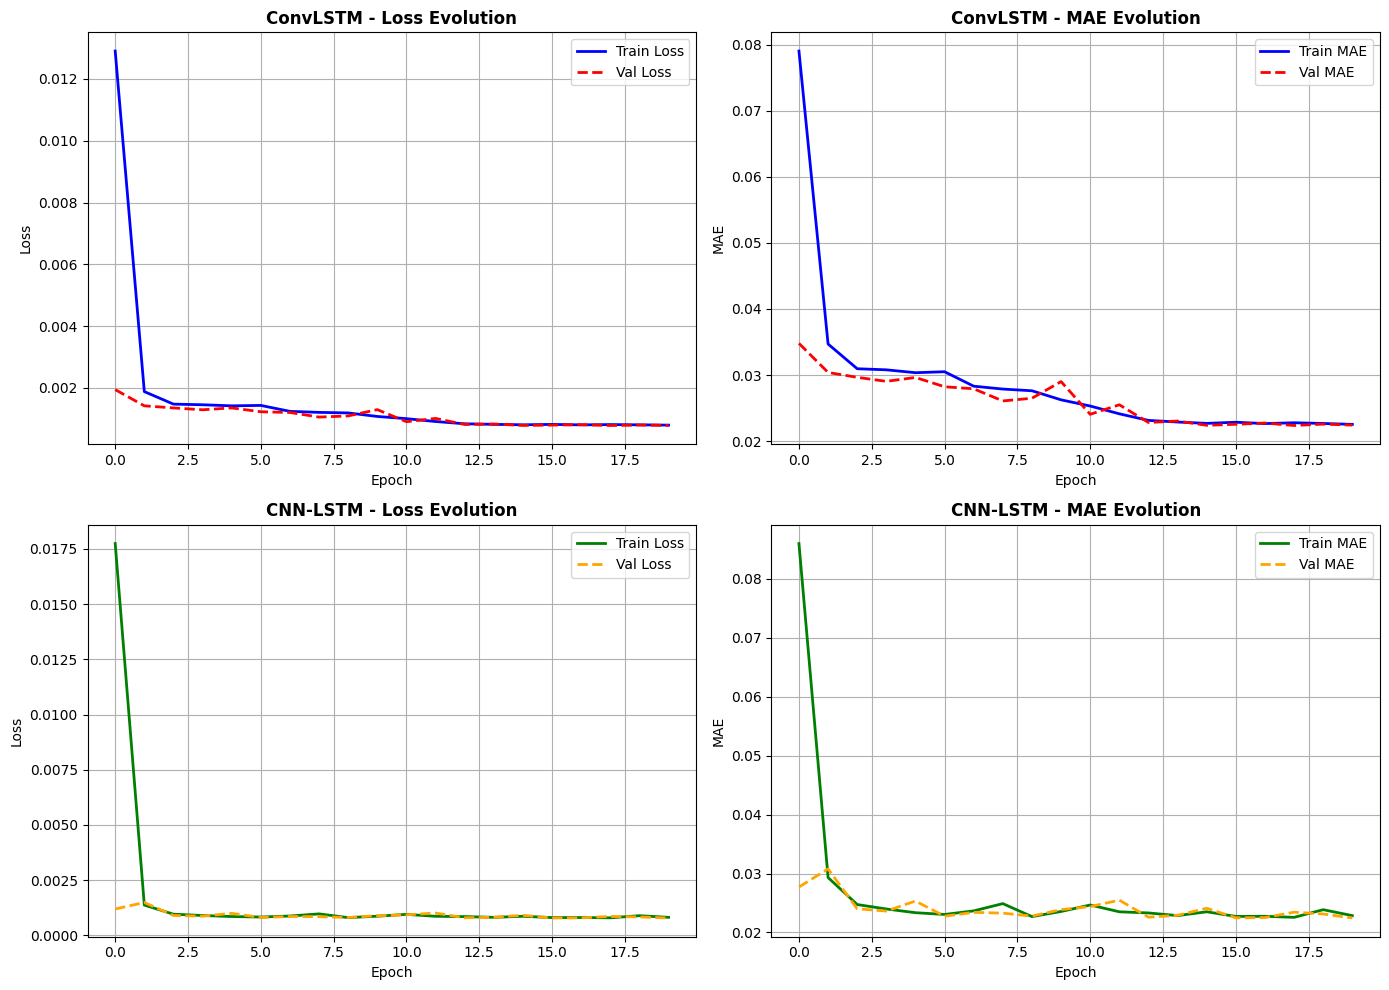

In [ ]:
print("\nPlotting training history for Indian Ocean...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ConvLSTM Loss
axes[0, 0].plot(hist_convlstm_i.history['loss'], 'b-', label='Train Loss', linewidth=2)
axes[0, 0].plot(hist_convlstm_i.history['val_loss'], 'r--', label='Val Loss', linewidth=2)
axes[0, 0].set_title('ConvLSTM - Loss Evolution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# ConvLSTM MAE
axes[0, 1].plot(hist_convlstm_i.history['mae'], 'b-', label='Train MAE', linewidth=2)
axes[0, 1].plot(hist_convlstm_i.history['val_mae'], 'r--', label='Val MAE', linewidth=2)
axes[0, 1].set_title('ConvLSTM - MAE Evolution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend()
axes[0, 1].grid(True)

# CNN-LSTM Loss
axes[1, 0].plot(hist_cnnlstm_i.history['loss'], 'g-', label='Train Loss', linewidth=2)
axes[1, 0].plot(hist_cnnlstm_i.history['val_loss'], 'orange', linestyle='--', label='Val Loss', linewidth=2)
axes[1, 0].set_title('CNN-LSTM - Loss Evolution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

# CNN-LSTM MAE
axes[1, 1].plot(hist_cnnlstm_i.history['mae'], 'g-', label='Train MAE', linewidth=2)
axes[1, 1].plot(hist_cnnlstm_i.history['val_mae'], 'orange', linestyle='--', label='Val MAE', linewidth=2)
axes[1, 1].set_title('CNN-LSTM - MAE Evolution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('MAE')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('training_history_indian_ocean.png', dpi=300, bbox_inches='tight')
plt.show()




Plotting training history for Pacific Ocean...


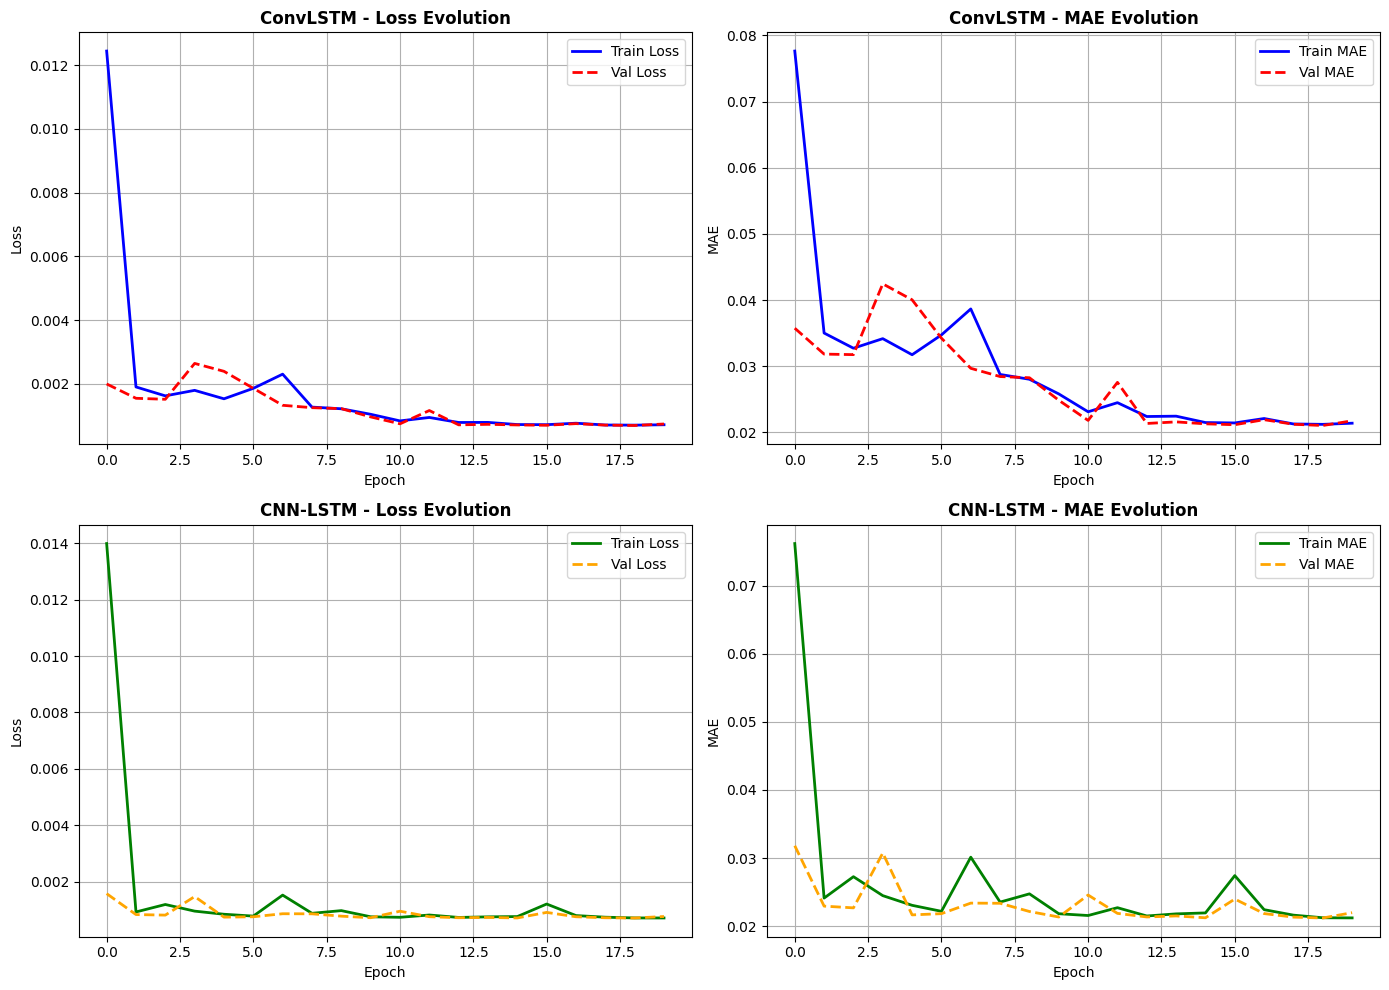

In [ ]:
print("\nPlotting training history for Pacific Ocean...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ConvLSTM Loss
axes[0, 0].plot(hist_convlstm_p.history['loss'], 'b-', label='Train Loss', linewidth=2)
axes[0, 0].plot(hist_convlstm_p.history['val_loss'], 'r--', label='Val Loss', linewidth=2)
axes[0, 0].set_title('ConvLSTM - Loss Evolution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# ConvLSTM MAE
axes[0, 1].plot(hist_convlstm_p.history['mae'], 'b-', label='Train MAE', linewidth=2)
axes[0, 1].plot(hist_convlstm_p.history['val_mae'], 'r--', label='Val MAE', linewidth=2)
axes[0, 1].set_title('ConvLSTM - MAE Evolution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend()
axes[0, 1].grid(True)

# CNN-LSTM Loss
axes[1, 0].plot(hist_cnnlstm_p.history['loss'], 'g-', label='Train Loss', linewidth=2)
axes[1, 0].plot(hist_cnnlstm_p.history['val_loss'], 'orange', linestyle='--', label='Val Loss', linewidth=2)
axes[1, 0].set_title('CNN-LSTM - Loss Evolution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

# CNN-LSTM MAE
axes[1, 1].plot(hist_cnnlstm_p.history['mae'], 'g-', label='Train MAE', linewidth=2)
axes[1, 1].plot(hist_cnnlstm_p.history['val_mae'], 'orange', linestyle='--', label='Val MAE', linewidth=2)
axes[1, 1].set_title('CNN-LSTM - MAE Evolution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('MAE')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('training_history_pacific_ocean.png', dpi=300, bbox_inches='tight')
plt.show()



VISUALIZATION: INDIAN OCEAN SST MAPS


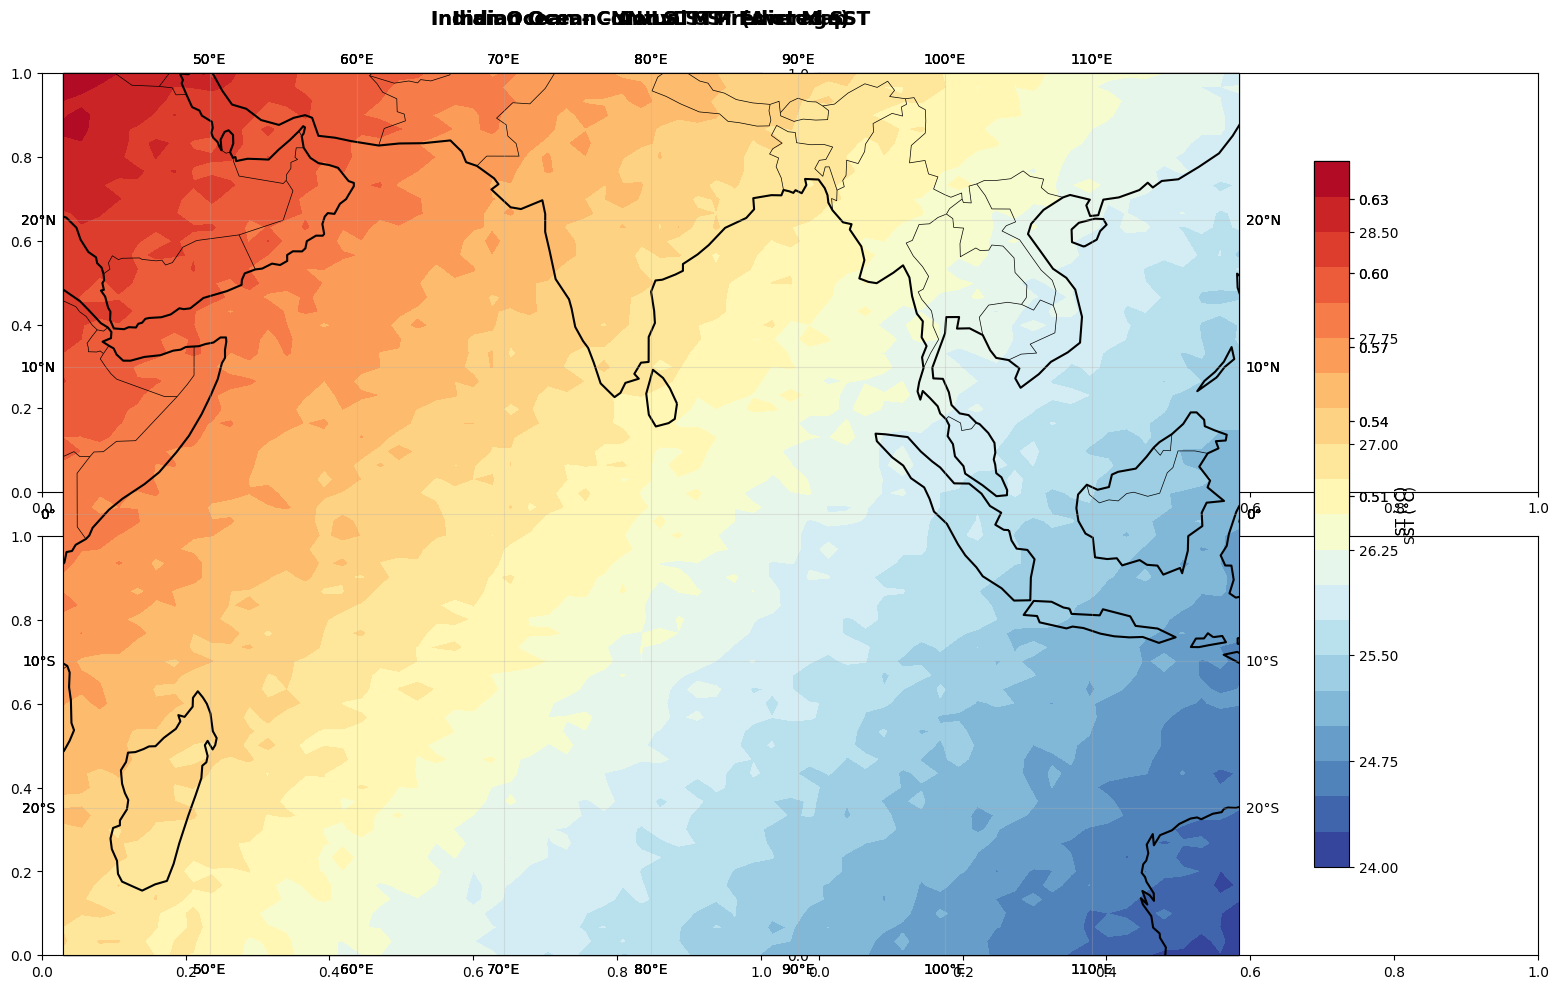

In [ ]:
def plot_sst_map(data, title, ocean_region):
    """Plot SST data on geographical map"""

    if ocean_region == "Indian Ocean":
        lon_min, lon_max = 40, 120
        lat_min, lat_max = -30, 30
    else:  # Pacific Ocean
        lon_min, lon_max = 110, 180
        lat_min, lat_max = -30, 30

    lons = np.linspace(lon_min, lon_max, data.shape[1])
    lats = np.linspace(lat_min, lat_max, data.shape[0])

    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    im = ax.contourf(lons, lats, data, cmap='RdYlBu_r', levels=20,
                     transform=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=1.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.gridlines(draw_labels=True, alpha=0.3)

    cbar = plt.colorbar(im, label='SST (°C)', shrink=0.8, ax=ax)
    plt.title(title, fontsize=14, fontweight='bold', pad=20)

    return ax

print("\n" + "="*60)
print("VISUALIZATION: INDIAN OCEAN SST MAPS")
print("="*60)

fig = plt.figure(figsize=(16, 10))

# Actual Indian Ocean
plt.subplot(2, 2, 1)
indian_actual = np.mean(indian_data[:50], axis=0)
plot_sst_map(indian_actual, 'Indian Ocean - Actual SST (Average)', 'Indian Ocean')

# Predicted Indian Ocean (ConvLSTM)
plt.subplot(2, 2, 2)
indian_pred_convlstm = y_pred_convlstm_i[0, :, :, 0] if len(y_pred_convlstm_i.shape) == 4 else y_pred_convlstm_i[0]
plot_sst_map(indian_pred_convlstm, 'Indian Ocean - ConvLSTM Predicted SST', 'Indian Ocean')

# Predicted Indian Ocean (CNN-LSTM)
plt.subplot(2, 2, 3)
indian_pred_cnnlstm = y_pred_cnnlstm_i[0, :, :, 0] if len(y_pred_cnnlstm_i.shape) == 4 else y_pred_cnnlstm_i[0]
plot_sst_map(indian_pred_cnnlstm, 'Indian Ocean - CNN-LSTM Predicted SST', 'Indian Ocean')

# Difference Map
plt.subplot(2, 2, 4)
difference = np.abs(indian_actual - indian_pred_convlstm)
plot_sst_map(difference, 'Indian Ocean - ConvLSTM Error Map', 'Indian Ocean')

plt.tight_layout()
plt.savefig('sst_maps_indian_ocean.png', dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
print("\n" + "="*60)
print("VISUALIZATION: PACIFIC OCEAN SST MAPS")
print("="*60)

fig = plt.figure(figsize=(16, 10))

# Actual Pacific Ocean
plt.subplot(2, 2, 1)
pacific_actual = np.mean(pacific_data[:50], axis=0)
plot_sst_map(pacific_actual, 'Pacific Ocean - Actual SST (Average)', 'Pacific Ocean')

# Predicted Pacific Ocean (ConvLSTM)
plt.subplot(2, 2, 2)
pacific_pred_convlstm = y_pred_convlstm_p[0, :, :, 0] if len(y_pred_convlstm_p.shape) == 4 else y_pred_convlstm_p[0]
plot_sst_map(pacific_pred_convlstm, 'Pacific Ocean - ConvLSTM Predicted SST', 'Pacific Ocean')

# Predicted Pacific Ocean (CNN-LSTM)
plt.subplot(2, 2, 3)
pacific_pred_cnnlstm = y_pred_cnnlstm_p[0, :, :, 0] if len(y_pred_cnnlstm_p.shape) == 4 else y_pred_cnnlstm_p[0]
plot_sst_map(pacific_pred_cnnlstm, 'Pacific Ocean - CNN-LSTM Predicted SST', 'Pacific Ocean')

# Difference Map
plt.subplot(2, 2, 4)
difference = np.abs(pacific_actual - pacific_pred_convlstm)
plot_sst_map(difference, 'Pacific Ocean - ConvLSTM Error Map', 'Pacific Ocean')

plt.tight_layout()
plt.savefig('sst_maps_pacific_ocean.png', dpi=300, bbox_inches='tight')
plt.show()



MODEL PERFORMANCE COMPARISON


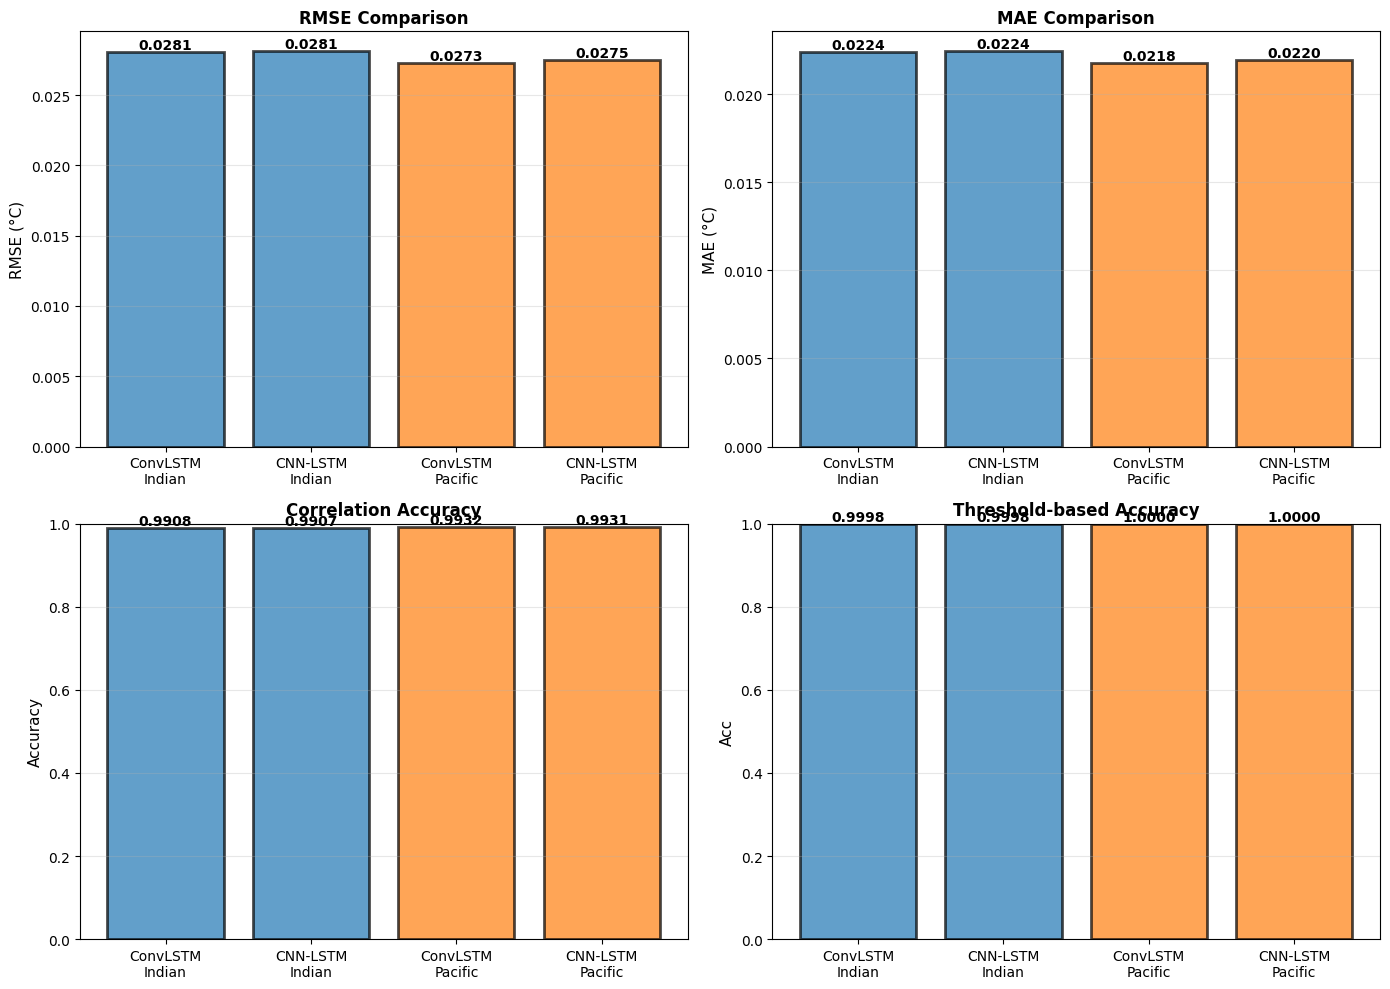

In [ ]:
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = ['ConvLSTM\nIndian', 'CNN-LSTM\nIndian', 'ConvLSTM\nPacific', 'CNN-LSTM\nPacific']
rmse_values = [metrics_convlstm_i['RMSE'], metrics_cnnlstm_i['RMSE'],
               metrics_convlstm_p['RMSE'], metrics_cnnlstm_p['RMSE']]
mae_values = [metrics_convlstm_i['MAE'], metrics_cnnlstm_i['MAE'],
              metrics_convlstm_p['MAE'], metrics_cnnlstm_p['MAE']]
accuracy_values = [metrics_convlstm_i['Accuracy'], metrics_cnnlstm_i['Accuracy'],
                   metrics_convlstm_p['Accuracy'], metrics_cnnlstm_p['Accuracy']]
acc_values = [metrics_convlstm_i['Acc'], metrics_cnnlstm_i['Acc'],
              metrics_convlstm_p['Acc'], metrics_cnnlstm_p['Acc']]

# RMSE Comparison
colors = ['#1f77b4', '#1f77b4', '#ff7f0e', '#ff7f0e']
bars1 = axes[0, 0].bar(models, rmse_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 0].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('RMSE (°C)', fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, rmse_values):
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# MAE Comparison
bars2 = axes[0, 1].bar(models, mae_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 1].set_title('MAE Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('MAE (°C)', fontsize=11)
axes[0, 1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, mae_values):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Accuracy Comparison
bars3 = axes[1, 0].bar(models, accuracy_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].set_title('Correlation Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Accuracy', fontsize=11)
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars3, accuracy_values):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Acc Comparison (Threshold-based)
bars4 = axes[1, 1].bar(models, acc_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 1].set_title('Threshold-based Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Acc', fontsize=11)
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars4, acc_values):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
print("\n" + "="*60)
print("DETAILED METRICS COMPARISON TABLE")
print("="*60)

comparison_data = {
    'Metric': ['RMSE', 'MAE', 'Accuracy', 'Acc'],
    'ConvLSTM-Indian': [f"{metrics_convlstm_i['RMSE']:.6f}",
                        f"{metrics_convlstm_i['MAE']:.6f}",
                        f"{metrics_convlstm_i['Accuracy']:.6f}",
                        f"{metrics_convlstm_i['Acc']:.6f}"],
    'CNN-LSTM-Indian': [f"{metrics_cnnlstm_i['RMSE']:.6f}",
                        f"{metrics_cnnlstm_i['MAE']:.6f}",
                        f"{metrics_cnnlstm_i['Accuracy']:.6f}",
                        f"{metrics_cnnlstm_i['Acc']:.6f}"],
    'ConvLSTM-Pacific': [f"{metrics_convlstm_p['RMSE']:.6f}",
                         f"{metrics_convlstm_p['MAE']:.6f}",
                         f"{metrics_convlstm_p['Accuracy']:.6f}",
                         f"{metrics_convlstm_p['Acc']:.6f}"],
    'CNN-LSTM-Pacific': [f"{metrics_cnnlstm_p['RMSE']:.6f}",
                         f"{metrics_cnnlstm_p['MAE']:.6f}",
                         f"{metrics_cnnlstm_p['Accuracy']:.6f}",
                         f"{metrics_cnnlstm_p['Acc']:.6f}"]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


In [ ]:
print("\n" + "="*60)
print("MODEL ARCHITECTURE SUMMARY")
print("="*60)

architecture_data = {
    'Component': [
        'Input Layer',
        'Layer 1',
        'Layer 2',
        'Layer 3',
        'Layer 4',
        'Output Layer'
    ],
    'ConvLSTM': [
        '(10, 64, 64, 1)',
        'ConvLSTM2D(32, 3×3, relu)',
        'ConvLSTM2D(64, 3×3, relu)',
        'ConvLSTM2D(32, 3×3, relu)',
        'Conv2D(1, 3×3, sigmoid)',
        '(64, 64, 1)'
    ],
    'CNN-LSTM': [
        '(10, 64, 64, 1)',
        'TimeDistributed Conv2D(32, 3×3, relu)',
        'TimeDistributed Conv2D(64, 3×3, relu)',
        'LSTM(128, relu) + LSTM(64, relu)',
        'Dense + Conv2D(1, 3×3, sigmoid)',
        '(64, 64, 1)'
    ]
}

architecture_df = pd.DataFrame(architecture_data)
print(architecture_df.to_string(index=False))



MODEL ARCHITECTURE SUMMARY
   Component                  ConvLSTM                              CNN-LSTM
 Input Layer           (10, 64, 64, 1)                       (10, 64, 64, 1)
     Layer 1 ConvLSTM2D(32, 3×3, relu) TimeDistributed Conv2D(32, 3×3, relu)
     Layer 2 ConvLSTM2D(64, 3×3, relu) TimeDistributed Conv2D(64, 3×3, relu)
     Layer 3 ConvLSTM2D(32, 3×3, relu)      LSTM(128, relu) + LSTM(64, relu)
     Layer 4   Conv2D(1, 3×3, sigmoid)       Dense + Conv2D(1, 3×3, sigmoid)
Output Layer               (64, 64, 1)                           (64, 64, 1)


In [ ]:
print("\n" + "="*60)
print("TRAINING PARAMETERS SUMMARY")
print("="*60)

training_params = {
    'Parameter': [
        'Sequence Length (Lookback)',
        'Input Shape',
        'Epochs',
        'Batch Size',
        'Learning Rate',
        'Optimizer',
        'Loss Function',
        'Activation (Hidden)',
        'Activation (Output)',
        'Data Split (Train/Test)',
        'Spatial Resolution',
        'Temporal Resolution'
    ],
    'Value': [
        '10 time steps',
        '(10, 64, 64, 1)',
        '20',
        '16',
        '0.001',
        'Adam',
        'MSE (Mean Squared Error)',
        'ReLU',
        'Sigmoid',
        '80% / 20%',
        '64 × 64 pixels',
        'Daily (~1825 days total for 5 years)'
    ]
}

training_df = pd.DataFrame(training_params)
print(training_df.to_string(index=False))

In [ ]:
print("\n" + "="*60)
print("DATA SUMMARY")
print("="*60)

data_info = {
    'Region': ['Indian Ocean', 'Pacific Ocean'],
    'Original Shape': [indian_data.shape, pacific_data.shape],
    'Latitude Range': ['30°S - 30°N', '30°S - 30°N'],
    'Longitude Range': ['40°E - 120°E', '110°E - 180°E'],
    'Time Period': ['2020-2025 (5 years)', '2020-2025 (5 years)'],
    'Time Steps': ['1825 days', '1825 days'],
    'Spatial Dim': ['64 × 64 pixels', '64 × 64 pixels'],
    'Total Samples (train)': [X_train_i.shape[0], X_train_p.shape[0]],
    'Total Samples (test)': [X_test_i.shape[0], X_test_p.shape[0]]
}

data_df = pd.DataFrame(data_info)
print(data_df.to_string(index=False))

In [ ]:
print("\n" + "="*60)
print("PREDICTION ERROR ANALYSIS")
print("="*60)

# Calculate error statistics for Indian Ocean
y_test_i_flat = y_test_i.reshape(-1)
y_pred_convlstm_i_flat = y_pred_convlstm_i.reshape(-
1)
y_pred_cnnlstm_i_flat = y_pred_cnnlstm_i.reshape(-1)

convlstm_i_errors = np.abs(y_test_i_flat - y_pred_convlstm_i_flat)
cnnlstm_i_errors = np.abs(y_test_i_flat - y_pred_cnnlstm_i_flat)

# Calculate error statistics for Pacific Ocean
y_test_p_flat = y_test_p.reshape(-1)
y_pred_convlstm_p_flat = y_pred_convlstm_p.reshape(-1)
y_pred_cnnlstm_p_flat = y_pred_cnnlstm_p.reshape(-1)

convlstm_p_errors = np.abs(y_test_p_flat - y_pred_convlstm_p_flat)
cnnlstm_p_errors = np.abs(y_test_p_flat - y_pred_cnnlstm_p_flat)

error_analysis = {
    'Metric': ['Min Error', 'Max Error', 'Mean Error', 'Median Error', 'Std Dev Error', 'Q1 Error', 'Q3 Error'],
    'ConvLSTM-Indian': [
        f"{np.min(convlstm_i_errors):.6f}",
        f"{np.max(convlstm_i_errors):.6f}",
        f"{np.mean(convlstm_i_errors):.6f}",
        f"{np.median(convlstm_i_errors):.6f}",
        f"{np.std(convlstm_i_errors):.6f}",
        f"{np.percentile(convlstm_i_errors, 25):.6f}",
        f"{np.percentile(convlstm_i_errors, 75):.6f}"
    ],
    'CNN-LSTM-Indian': [
        f"{np.min(cnnlstm_i_errors):.6f}",
        f"{np.max(cnnlstm_i_errors):.6f}",
        f"{np.mean(cnnlstm_i_errors):.6f}",
        f"{np.median(cnnlstm_i_errors):.6f}",
        f"{np.std(cnnlstm_i_errors):.6f}",
        f"{np.percentile(cnnlstm_i_errors, 25):.6f}",
        f"{np.percentile(cnnlstm_i_errors, 75):.6f}"
    ],
    'ConvLSTM-Pacific': [
        f"{np.min(convlstm_p_errors):.6f}",
        f"{np.max(convlstm_p_errors):.6f}",
        f"{np.mean(convlstm_p_errors):.6f}",
        f"{np.median(convlstm_p_errors):.6f}",
        f"{np.std(convlstm_p_errors):.6f}",
        f"{np.percentile(convlstm_p_errors, 25):.6f}",
        f"{np.percentile(convlstm_p_errors, 75):.6f}"
    ],
    'CNN-LSTM-Pacific': [
        f"{np.min(cnnlstm_p_errors):.6f}",
        f"{np.max(cnnlstm_p_errors):.6f}",
        f"{np.mean(cnnlstm_p_errors):.6f}",
        f"{np.median(cnnlstm_p_errors):.6f}",
        f"{np.std(cnnlstm_p_errors):.6f}",
        f"{np.percentile(cnnlstm_p_errors, 25):.6f}",
        f"{np.percentile(cnnlstm_p_errors, 75):.6f}"
    ]
}

error_df = pd.DataFrame(error_analysis)
print(error_df.to_string(index=False))

In [ ]:
print("\nPlotting error distributions...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(convlstm_i_errors, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_title('ConvLSTM - Indian Ocean Error Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Absolute Error (°C)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(cnnlstm_i_errors, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].set_title('CNN-LSTM - Indian Ocean Error Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Absolute Error (°C)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(convlstm_p_errors, bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1, 0].set_title('ConvLSTM - Pacific Ocean Error Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Absolute Error (°C)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(cnnlstm_p_errors, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1, 1].set_title('CNN-LSTM - Pacific Ocean Error Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Absolute Error (°C)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=300, bbox_inches='tight')
plt.show()



Plotting prediction vs actual comparison...


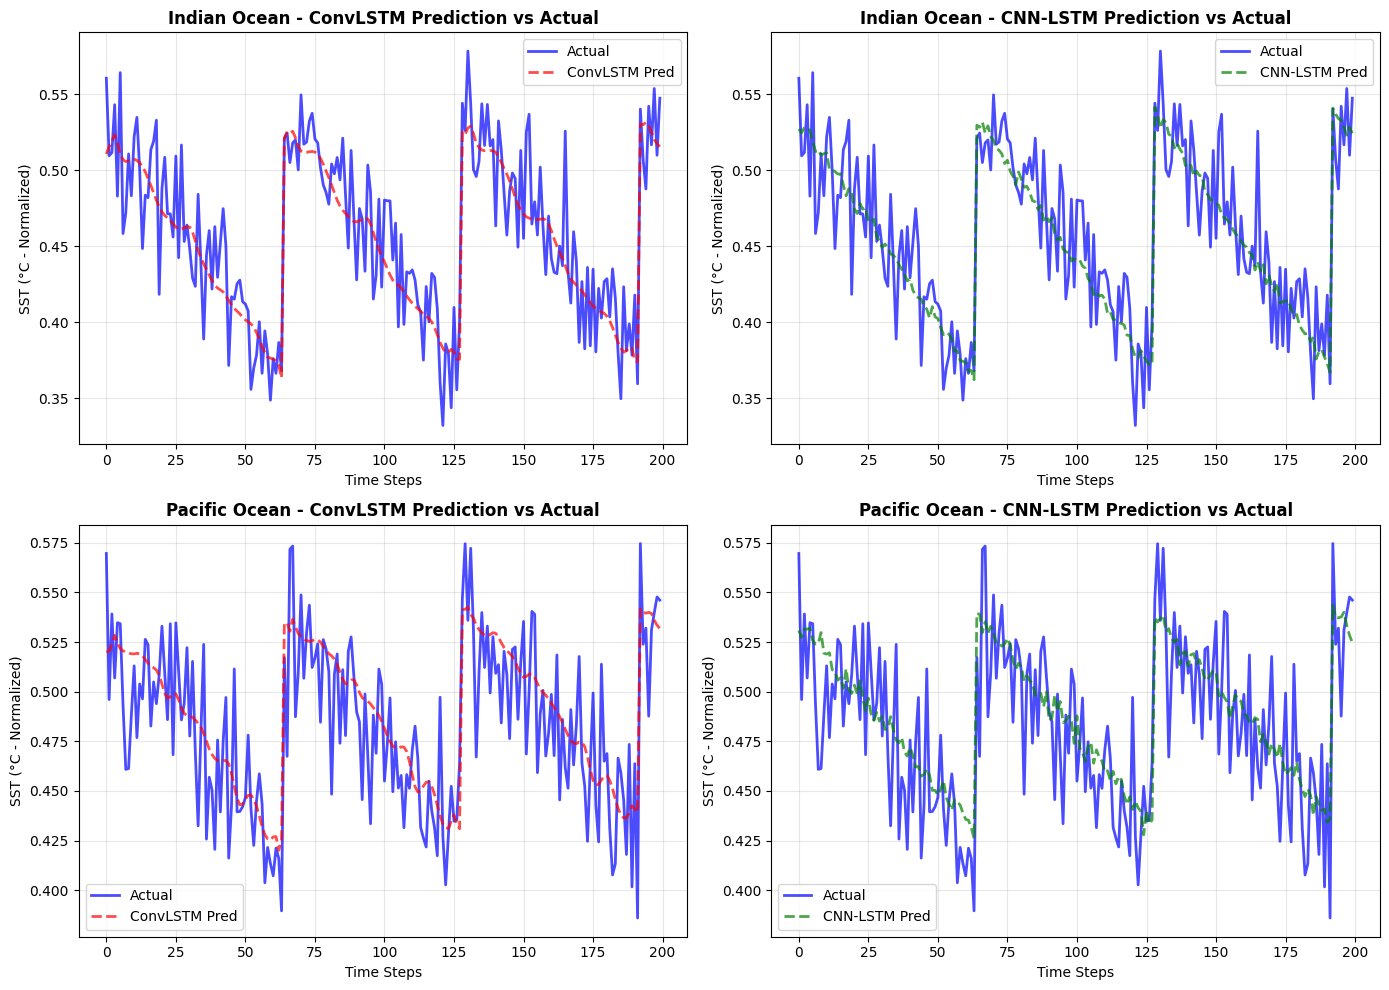

In [ ]:
print("\nPlotting prediction vs actual comparison...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Indian Ocean ConvLSTM
sample_size = min(200, len(y_test_i_flat))
axes[0, 0].plot(y_test_i_flat[:sample_size], 'b-', label='Actual', linewidth=2, alpha=0.7)
axes[0, 0].plot(y_pred_convlstm_i_flat[:sample_size], 'r--', label='ConvLSTM Pred', linewidth=2, alpha=0.7)
axes[0, 0].set_title('Indian Ocean - ConvLSTM Prediction vs Actual', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Time Steps')
axes[0, 0].set_ylabel('SST (°C - Normalized)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Indian Ocean CNN-LSTM
axes[0, 1].plot(y_test_i_flat[:sample_size], 'b-', label='Actual', linewidth=2, alpha=0.7)
axes[0, 1].plot(y_pred_cnnlstm_i_flat[:sample_size], 'g--', label='CNN-LSTM Pred', linewidth=2, alpha=0.7)
axes[0, 1].set_title('Indian Ocean - CNN-LSTM Prediction vs Actual', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Time Steps')
axes[0, 1].set_ylabel('SST (°C - Normalized)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Pacific Ocean ConvLSTM
axes[1, 0].plot(y_test_p_flat[:sample_size], 'b-', label='Actual', linewidth=2, alpha=0.7)
axes[1, 0].plot(y_pred_convlstm_p_flat[:sample_size], 'r--', label='ConvLSTM Pred', linewidth=2, alpha=0.7)
axes[1, 0].set_title('Pacific Ocean - ConvLSTM Prediction vs Actual', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Time Steps')
axes[1, 0].set_ylabel('SST (°C - Normalized)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Pacific Ocean CNN-LSTM
axes[1, 1].plot(y_test_p_flat[:sample_size], 'b-', label='Actual', linewidth=2, alpha=0.7)
axes[1, 1].plot(y_pred_cnnlstm_p_flat[:sample_size], 'g--', label='CNN-LSTM Pred', linewidth=2, alpha=0.7)
axes[1, 1].set_title('Pacific Ocean - CNN-LSTM Prediction vs Actual', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Time Steps')
axes[1, 1].set_ylabel('SST (°C - Normalized)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

